In [1]:
import pandas as pd
import numpy as np

In [7]:
churn_df= pd.read_excel("churn.xlsx")

In [11]:
churn_df = pd.read_excel("churn.xlsx", header=None)

In [12]:
churn_df = churn_df[0].str.split(",", expand=True)

In [13]:
churn_df.columns = [
    "CustomerID","Age","Gender","Tenure","Usage Frequency",
    "Support Calls","Payment Delay","Subscription Type",
    "Contract Length","Total Spend","Last Interaction","Churn"
]

In [14]:
churn_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
1,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
2,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
3,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
4,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0


In [15]:
churn_df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [16]:
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64375 entries, 0 to 64374
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64375 non-null  object
 1   Age                64375 non-null  object
 2   Gender             64375 non-null  object
 3   Tenure             64375 non-null  object
 4   Usage Frequency    64375 non-null  object
 5   Support Calls      64375 non-null  object
 6   Payment Delay      64375 non-null  object
 7   Subscription Type  64375 non-null  object
 8   Contract Length    64375 non-null  object
 9   Total Spend        64375 non-null  object
 10  Last Interaction   64375 non-null  object
 11  Churn              64375 non-null  object
dtypes: object(12)
memory usage: 5.9+ MB


In [17]:
churn_df.dtypes

CustomerID           object
Age                  object
Gender               object
Tenure               object
Usage Frequency      object
Support Calls        object
Payment Delay        object
Subscription Type    object
Contract Length      object
Total Spend          object
Last Interaction     object
Churn                object
dtype: object

In [18]:
from sklearn.preprocessing import LabelEncoder

In [19]:
le=LabelEncoder()

In [20]:
churn_df=churn_df.drop(columns=['CustomerID'])

In [21]:
churn_df

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
3,47,Male,27,10,2,29,Premium,Annual,757,21,0
4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
...,...,...,...,...,...,...,...,...,...,...,...
64370,45,Female,33,12,6,21,Basic,Quarterly,947,14,1
64371,37,Male,6,1,5,22,Standard,Annual,923,9,1
64372,25,Male,39,14,8,30,Premium,Monthly,327,20,1
64373,50,Female,18,19,7,22,Standard,Monthly,540,13,1


In [22]:
churn_df['Churn'] = churn_df['Churn'].fillna(0.0)

In [23]:
cat_col=['Gender','Subscription Type','Contract Length']
le_dict={}
for col in cat_col:
    le=LabelEncoder()
    churn_df[col] = le.fit_transform(churn_df[col].astype(str))
    le_dict[col] = le 

In [24]:
churn_df

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,Age,1,Tenure,Usage Frequency,Support Calls,Payment Delay,3,1,Total Spend,Last Interaction,Churn
1,22,0,25,14,4,27,0,2,598,9,1
2,41,0,28,28,7,13,2,2,584,20,0
3,47,2,27,10,2,29,1,0,757,21,0
4,35,2,9,12,5,17,1,3,232,18,0
...,...,...,...,...,...,...,...,...,...,...,...
64370,45,0,33,12,6,21,0,3,947,14,1
64371,37,2,6,1,5,22,2,0,923,9,1
64372,25,2,39,14,8,30,1,2,327,20,1
64373,50,0,18,19,7,22,2,2,540,13,1


In [25]:
from sklearn.preprocessing import StandardScaler

In [38]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
churn_df[num_col] = imputer.fit_transform(churn_df[num_col])


In [39]:
scaler=StandardScaler()

In [40]:
num_col = [
    'Age','Tenure','Usage Frequency','Support Calls',
    'Payment Delay','Total Spend','Last Interaction'
]

# Convert columns to numeric
for col in num_col:
    churn_df[col] = pd.to_numeric(churn_df[col], errors='coerce')

In [41]:
churn_df[num_col]=scaler.fit_transform(churn_df[num_col])

In [42]:
churn_df

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,0.002084,1,0.058788,-0.009100,0.192456,0.210800,3,1,-0.026922,-0.057748,Churn
1,-1.434213,0,-0.409104,-0.122526,-0.449813,1.114543,0,2,0.218410,-0.752329,1
2,-0.069731,0,-0.233644,1.465435,0.513591,-0.467007,2,2,0.164743,0.521070,0
3,0.361158,2,-0.292131,-0.576230,-1.092083,1.340479,1,0,0.827907,0.636833,0
4,-0.500620,2,-1.344887,-0.349378,-0.128678,-0.015135,1,3,-1.184584,0.289543,0
...,...,...,...,...,...,...,...,...,...,...,...
64370,0.217528,0,0.058788,-0.349378,0.192456,0.436736,0,3,1.556237,-0.173511,1
64371,-0.356990,2,-1.520347,-1.597062,-0.128678,0.549704,2,0,1.464237,-0.752329,1
64372,-1.218769,2,0.409707,-0.122526,0.834726,1.453446,1,2,-0.820419,0.521070,1
64373,0.576603,0,-0.818509,0.444603,0.513591,0.549704,2,2,-0.003923,-0.289275,1


In [43]:
from sklearn.model_selection import train_test_split

In [44]:
x=churn_df.drop(columns=['Churn'])
y=churn_df['Churn']

In [45]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [46]:
x_train

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction
13468,1.294751,2,-1.520347,-1.597062,1.476996,-1.709653,2,0,-0.498420,-0.289275
20118,-0.428805,2,0.526680,1.692287,-0.128678,0.210800,0,0,-1.061918,-1.678437
48411,0.863862,0,-1.578833,-1.370211,0.834726,-1.031846,0,3,0.379409,0.173779
42125,1.007492,0,-0.876996,0.331177,-0.128678,-1.483717,0,3,-0.007756,-0.057748
55119,-0.069731,0,0.643653,1.578861,0.834726,1.114543,2,3,-0.368088,-1.215383
...,...,...,...,...,...,...,...,...,...,...
62570,-1.721473,0,-0.116671,0.784880,0.192456,1.453446,0,2,0.402409,1.099887
38158,-1.075139,0,-0.175158,-0.462804,0.513591,0.210800,1,0,1.360738,1.562941
860,-1.218769,0,1.403977,1.692287,-1.734352,-0.015135,0,0,-0.571253,-0.983856
15795,1.582011,0,-0.233644,-1.256785,1.476996,-0.692943,1,3,0.038244,-0.636565


In [47]:
from sklearn.linear_model import LogisticRegression

In [48]:
model=LogisticRegression(max_iter=1000,random_state=42)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [49]:
from sklearn.metrics import accuracy_score,classification_report

In [50]:
y_pred=model.predict(x_test)

In [51]:
print("accuracy_score",accuracy_score(y_test,y_pred))

accuracy_score 0.8246990291262136


In [52]:
print("classification_report: \n",classification_report(y_test,y_pred))

classification_report: 
               precision    recall  f1-score   support

           0       0.84      0.82      0.83      6808
           1       0.81      0.83      0.82      6067

    accuracy                           0.82     12875
   macro avg       0.82      0.82      0.82     12875
weighted avg       0.83      0.82      0.82     12875



In [53]:
from sklearn.neighbors import KNeighborsClassifier

In [54]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train, y_train)

KNeighborsClassifier()

In [55]:
y_pred = knn.predict(x_test)

In [56]:
print("Accuracy:", accuracy_score(y_test,y_pred))
print("\nClassification Report:\n", classification_report(y_test,y_pred))

Accuracy: 0.913631067961165

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.89      0.92      6808
           1       0.88      0.94      0.91      6067

    accuracy                           0.91     12875
   macro avg       0.91      0.92      0.91     12875
weighted avg       0.92      0.91      0.91     12875



In [57]:
import matplotlib.pyplot as plt

In [58]:
import seaborn as sns

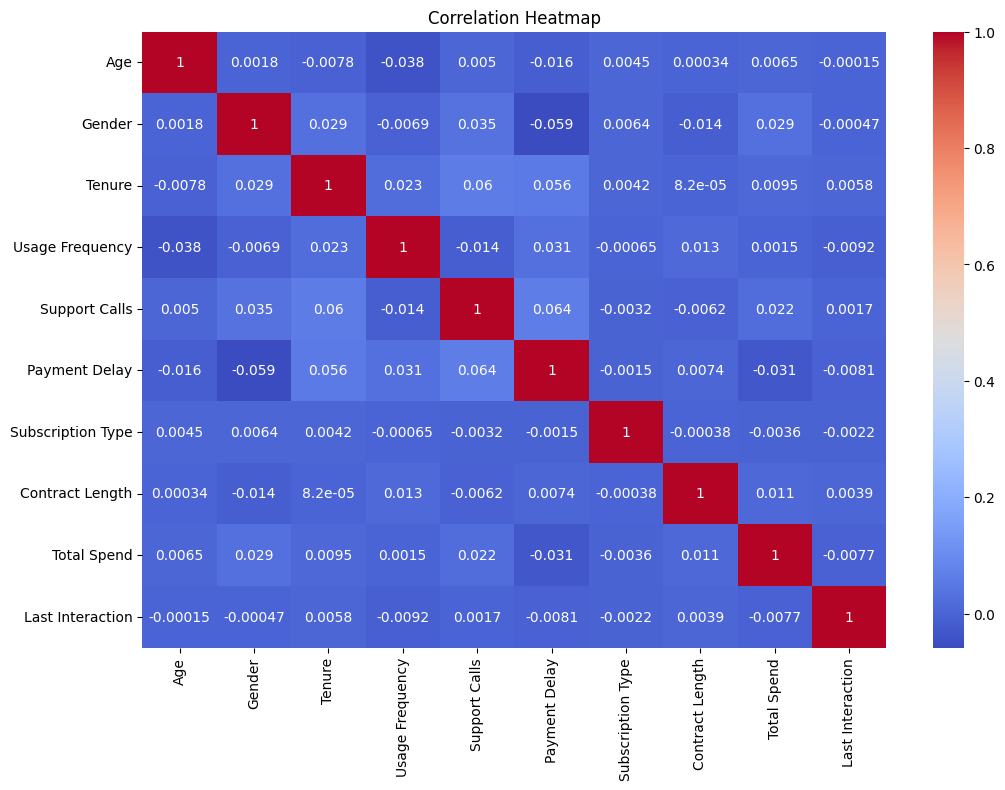

In [59]:
plt.figure(figsize=(12, 8))
sns.heatmap(churn_df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [60]:
sns.set(style="whitegrid")
features = ['Age', 'Tenure', 'Usage Frequency', 'Total Spend']

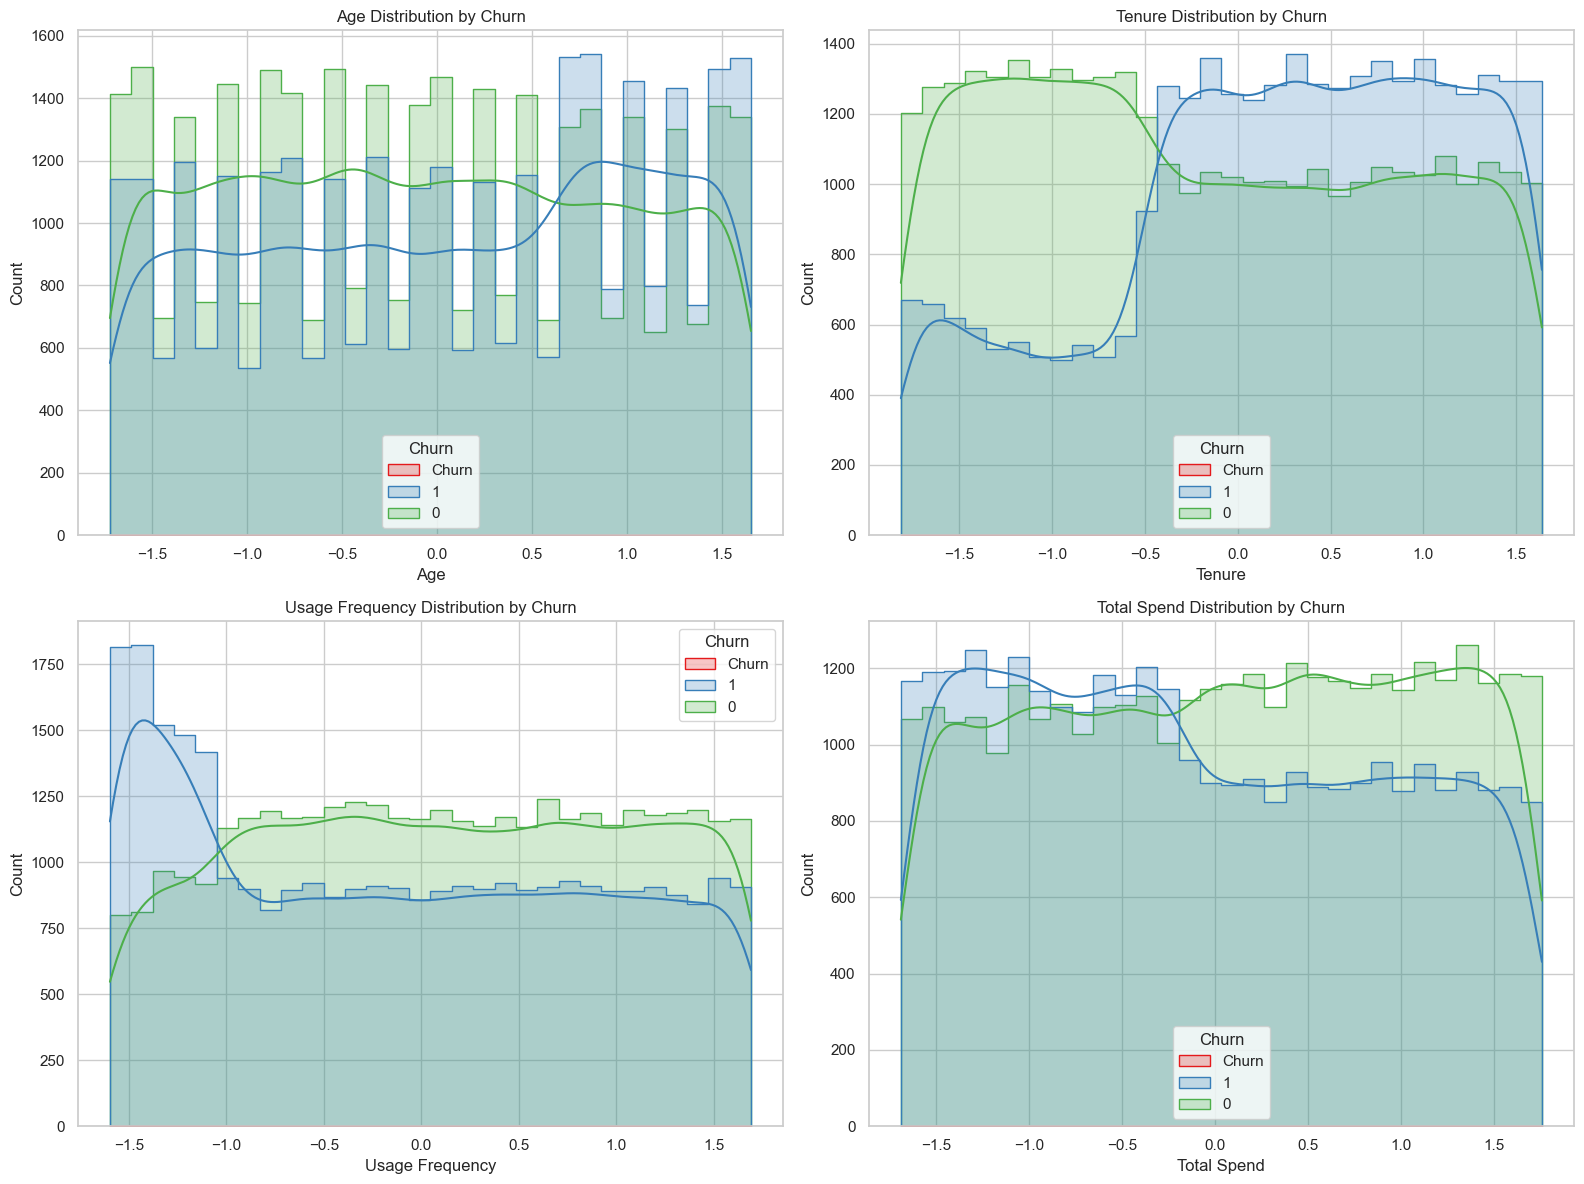

In [61]:
plt.figure(figsize=(16, 12))
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=churn_df, x=feature, hue='Churn', bins=30, kde=True, palette='Set1', element="step")
    plt.title(f'{feature} Distribution by Churn')
    plt.xlabel(feature)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

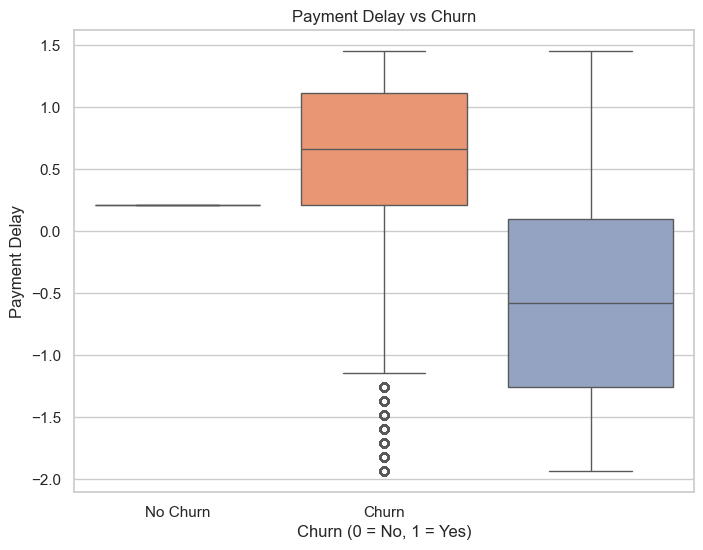

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(data=churn_df, x='Churn', y='Payment Delay', hue='Churn', palette='Set2', legend=False)
plt.title('Payment Delay vs Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Payment Delay')
plt.xticks([0, 1], ['No Churn', 'Churn'])

plt.show()

In [63]:
print(le_dict['Subscription Type'].classes_)

['Basic' 'Premium' 'Standard' 'Subscription Type']


In [64]:
import pandas as pd
user_input = [[30, 'Male', 12, 15, 2, 28, 'Basic', 'Monthly', 2000, 10]]


user_df = pd.DataFrame(user_input, columns=[
    'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
    'Payment Delay', 'Subscription Type', 'Contract Length',
    'Total Spend', 'Last Interaction'
])


for col in cat_col:
    user_df[col] = le_dict[col].transform(user_df[col].astype(str))


user_scaled = scaler.transform(user_df[num_col])

user_final = np.hstack((user_scaled, user_df[cat_col].values))
prediction = knn.predict(user_final)  # <-- NumPy array without feature names



print("Predicted Churn:", "1" if prediction[0] == 1 else "0")

Predicted Churn: 0


C:\Users\Yugant Manekar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [65]:
import pickle
import os

In [71]:
base_path = r"C:\Users\Yugant Manekar\OneDrive\Desktop\Resources\Customer Churn Prediction"
os.makedirs(base_path, exist_ok=True)

In [72]:
with open(os.path.join(base_path, 'knn_model.pkl'), 'wb') as f:
    pickle.dump(knn, f)

In [73]:
with open(os.path.join(base_path, 'scaler.pkl'), 'wb') as f:
    pickle.dump(scaler, f)

In [74]:
with open(os.path.join(base_path, 'le.pkl'), 'wb') as f:
    pickle.dump(le_dict, f)


In [75]:
col_data = {
    'cat_col': cat_col,
    'num_col': num_col
}

In [76]:
with open(os.path.join(base_path, 'columns.pkl'), 'wb') as f:
    pickle.dump(col_data, f)